## 1. Imports & Setup


In [1]:
import os, warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score,
    precision_recall_curve
)

from xgboost import XGBClassifier

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Input,
    MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

print("All imports successful.")
print("TensorFlow version:", tf.__version__)
print("Pandas version:", pd.__version__)

All imports successful.
TensorFlow version: 2.20.0
Pandas version: 2.2.2


## 2. Load Data


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/equipment_failure_detection/dataset/dataset_train.csv', index_col=0)

df['timestamp'] = pd.to_datetime(df['timestamp'])

df = df.sort_values('timestamp').reset_index(drop=True)

print("Loaded shape:", df.shape)
df.head(5)

Loaded shape: (1516948, 16)


,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


## 3. Data Exploration


In [4]:
print("Shape:", df.shape)
print()
print("Data types:")
print(df.dtypes)

Shape: (1516948, 16)

Data types:
timestamp          datetime64[ns]
TP2                       float64
TP3                       float64
H1                        float64
DV_pressure               float64
Reservoirs                float64
Oil_temperature           float64
Motor_current             float64
COMP                      float64
DV_eletric                float64
Towers                    float64
MPG                       float64
LPS                       float64
Pressure_switch           float64
Oil_level                 float64
Caudal_impulses           float64
dtype: object


In [5]:
print("First 10 rows:")
df.head(10)

First 10 rows:


,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
5,2020-02-01 00:00:49,-0.012,9.306,9.290,-0.024,9.308,53.500,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
6,2020-02-01 00:00:59,-0.012,9.296,9.280,-0.024,9.298,53.375,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
7,2020-02-01 00:01:09,-0.014,9.286,9.270,-0.024,9.286,53.550,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
8,2020-02-01 00:01:19,-0.012,9.276,9.258,-0.022,9.276,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
9,2020-02-01 00:01:29,-0.012,9.264,9.248,-0.022,9.264,53.375,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


In [6]:
print("Null counts per column:")
print(df.isnull().sum())

Null counts per column:
timestamp          0
TP2                0
TP3                0
H1                 0
DV_pressure        0
Reservoirs         0
Oil_temperature    0
Motor_current      0
COMP               0
DV_eletric         0
Towers             0
MPG                0
LPS                0
Pressure_switch    0
Oil_level          0
Caudal_impulses    0
dtype: int64


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
print("Zero-value count per column:")
print(df[df.eq(0)].count())

Zero-value count per column:
timestamp                0
TP2                    112
TP3                      0
H1                     384
DV_pressure            397
Reservoirs               0
Oil_temperature          0
Motor_current            0
COMP                247328
DV_eletric         1273310
Towers              121586
MPG                 253840
LPS                1511760
Pressure_switch      12990
Oil_level           145391
Caudal_impulses      95406
dtype: int64


In [9]:
print("Unique values per column:")
print(df.nunique())

Unique values per column:
timestamp          1516948
TP2                   5257
TP3                   3683
H1                    2665
DV_pressure           2257
Reservoirs            3682
Oil_temperature       2462
Motor_current         1809
COMP                     2
DV_eletric               2
Towers                   2
MPG                      2
LPS                      2
Pressure_switch          2
Oil_level                2
Caudal_impulses          2
dtype: int64


In [10]:
df['time_diff'] = df['timestamp'].diff().dt.total_seconds()
print("Sampling interval statistics (seconds):")
print(df['time_diff'].describe())

Sampling interval statistics (seconds):
count    1.516947e+06
mean     1.214122e+01
std      3.141073e+02
min      8.000000e+00
25%      1.000000e+01
50%      1.000000e+01
75%      1.000000e+01
max      1.729180e+05
Name: time_diff, dtype: float64


In [11]:
print("COMP value distribution (normalised):")
print(df['COMP'].value_counts(normalize=True))

COMP value distribution (normalised):
COMP
1.0    0.836957
0.0    0.163043
Name: proportion, dtype: float64


In [12]:
print("Total time span:", df['timestamp'].max() - df['timestamp'].min())

Total time span: 213 days 03:59:50


## 4. Preprocessing & Cleaning


In [13]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
df.drop(columns=constant_cols, inplace=True)
print("Removed constant columns:", constant_cols)
print("Shape after cleaning:", df.shape)

Removed constant columns: []
Shape after cleaning: (1516948, 17)


## 5. Target Engineering


In [14]:
df = df.sort_values('timestamp')

df['failure_event'] = ((df['COMP'].shift(1) == 1) & (df['COMP'] == 0)).astype(int)
print("Total failure events:", df['failure_event'].sum())

Total failure events: 16923


In [15]:
df['next_failure_time'] = df['timestamp'].where(df['failure_event'] == 1).bfill()
df['TTF_minutes'] = (df['next_failure_time'] - df['timestamp']).dt.total_seconds() / 60

print("TTF_minutes statistics:")
print(df['TTF_minutes'].describe())

TTF_minutes statistics:
count    1.516861e+06
mean     9.311400e+01
std      4.381374e+02
min      0.000000e+00
25%      5.283333e+00
50%      1.140000e+01
75%      1.866667e+01
max      4.579017e+03
Name: TTF_minutes, dtype: float64


In [16]:
horizon = 3
df['failure_next_3min'] = (df['TTF_minutes'] <= horizon).astype(int)

print("Binary target distribution (normalised):")
print(df['failure_next_3min'].value_counts(normalize=True))

Binary target distribution (normalised):
failure_next_3min
0    0.843603
1    0.156397
Name: proportion, dtype: float64


## 6. Feature Engineering


In [17]:
df['Motor_current_mean_5']   = df['Motor_current'].rolling(5).mean()
df['Motor_current_std_5']    = df['Motor_current'].rolling(5).std()
df['Oil_temperature_mean_5'] = df['Oil_temperature'].rolling(5).mean()
df['Oil_temperature_std_5']  = df['Oil_temperature'].rolling(5).std()
df['TP2_mean_5']             = df['TP2'].rolling(5).mean()
df['TP3_mean_5']             = df['TP3'].rolling(5).mean()

df['Motor_current_diff']   = df['Motor_current'].diff()
df['Oil_temperature_diff'] = df['Oil_temperature'].diff()
df['TP2_diff']             = df['TP2'].diff()
df['TP3_diff']             = df['TP3'].diff()

df['Motor_current_lag1']   = df['Motor_current'].shift(1)
df['Motor_current_lag2']   = df['Motor_current'].shift(2)
df['Oil_temperature_lag1'] = df['Oil_temperature'].shift(1)
df['Oil_temperature_lag2'] = df['Oil_temperature'].shift(2)

print("Shape after feature engineering:", df.shape)
print("New feature columns added:", 14)

Shape after feature engineering: (1516948, 35)
New feature columns added: 14


## 7. Handle Nulls & Sampling
Drop NaN rows introduced by rolling/diff/lag, then take a stratified 100k-row
proportional sample to keep memory manageable while preserving class ratios.

In [18]:
print("Shape before dropna:", df.shape)
df = df.dropna()
print("Shape after dropna:", df.shape)

Shape before dropna: (1516948, 35)
Shape after dropna: (1516857, 35)


In [19]:

print("Shape before temporal crop:", df.shape)

df = df.sort_values('timestamp').reset_index(drop=True)
df = df.tail(100_000).reset_index(drop=True)

print("Shape after temporal crop:", df.shape)
print("Class distribution:")
print(df['failure_next_3min'].value_counts(normalize=True))
print("Time span:", df['timestamp'].min(), "→", df['timestamp'].max())
print("Avg time diff (s):", df['timestamp'].diff().dt.total_seconds().mean().round(1))

Shape before temporal crop: (1516857, 35)
Shape after temporal crop: (100000, 35)
Class distribution:
failure_next_3min
0    0.82227
1    0.17773
Name: proportion, dtype: float64
Time span: 2020-08-17 18:17:01 → 2020-09-01 03:45:28
Avg time diff (s): 12.4


## 8. Temporal Train/Val/Test Split
Split 70/15/15 strictly by time order — NO shuffling. This preserves temporal
structure and prevents data leakage from future into past.

In [20]:
df = df.sort_values('timestamp').reset_index(drop=True)

features_candidate = [
    'TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs',
    'Oil_temperature', 'Motor_current',
    'COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS',
    'Pressure_switch', 'Oil_level', 'Caudal_impulses',
    'time_diff',
    'Motor_current_mean_5', 'Motor_current_std_5',
    'Oil_temperature_mean_5', 'Oil_temperature_std_5',
    'TP2_mean_5', 'TP3_mean_5',
    'Motor_current_diff', 'Oil_temperature_diff', 'TP2_diff', 'TP3_diff',
    'Motor_current_lag1', 'Motor_current_lag2',
    'Oil_temperature_lag1', 'Oil_temperature_lag2'
]
features = [f for f in features_candidate if f in df.columns]
print(f"Features used ({len(features)}):", features)

target = 'failure_next_3min'

n         = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df   = df.iloc[train_end:val_end]
test_df  = df.iloc[val_end:]

X_train, y_train = train_df[features], train_df[target]
X_val,   y_val   = val_df[features],   val_df[target]
X_test,  y_test  = test_df[features],  test_df[target]

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

Features used (30): ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current', 'COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses', 'time_diff', 'Motor_current_mean_5', 'Motor_current_std_5', 'Oil_temperature_mean_5', 'Oil_temperature_std_5', 'TP2_mean_5', 'TP3_mean_5', 'Motor_current_diff', 'Oil_temperature_diff', 'TP2_diff', 'TP3_diff', 'Motor_current_lag1', 'Motor_current_lag2', 'Oil_temperature_lag1', 'Oil_temperature_lag2']
Train: (70000, 30)
Val:   (15000, 30)
Test:  (15000, 30)


## 9. Exploratory Data Analysis (EDA)


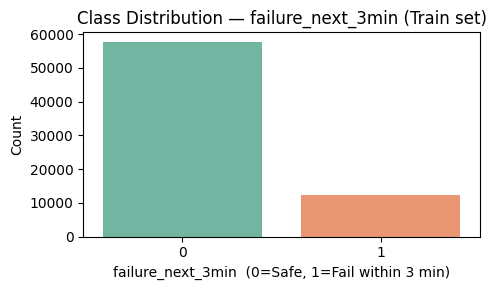

In [21]:
plt.figure(figsize=(5, 3))
sns.countplot(x='failure_next_3min', data=train_df, palette='Set2')
plt.title("Class Distribution — failure_next_3min (Train set)")
plt.xlabel("failure_next_3min  (0=Safe, 1=Fail within 3 min)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

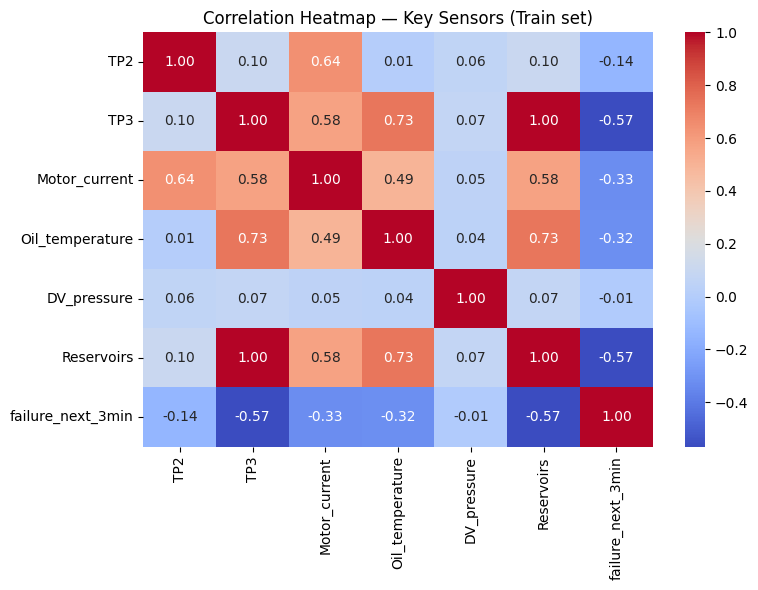

In [22]:
cols = ['TP2', 'TP3', 'Motor_current', 'Oil_temperature',
        'DV_pressure', 'Reservoirs', 'failure_next_3min']
plt.figure(figsize=(8, 6))
sns.heatmap(train_df[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap — Key Sensors (Train set)")
plt.tight_layout()
plt.show()

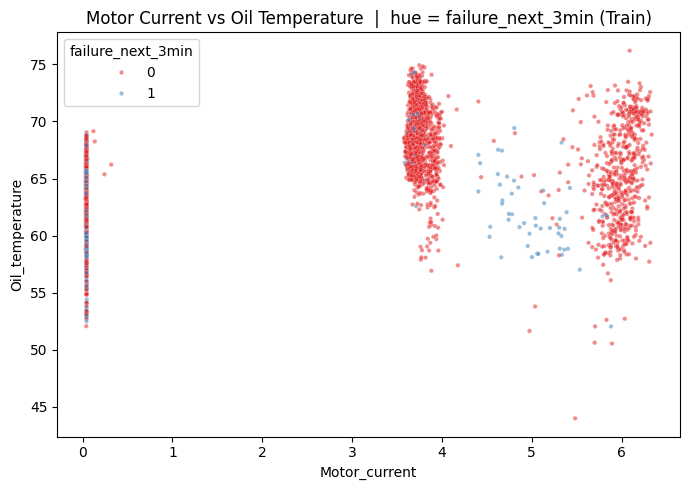

In [23]:
sample_eda = train_df.sample(5000, random_state=42)
plt.figure(figsize=(7, 5))
sns.scatterplot(data=sample_eda, x='Motor_current', y='Oil_temperature',
                hue='failure_next_3min', palette='Set1', alpha=0.5, s=10)
plt.title("Motor Current vs Oil Temperature  |  hue = failure_next_3min (Train)")
plt.tight_layout()
plt.show()

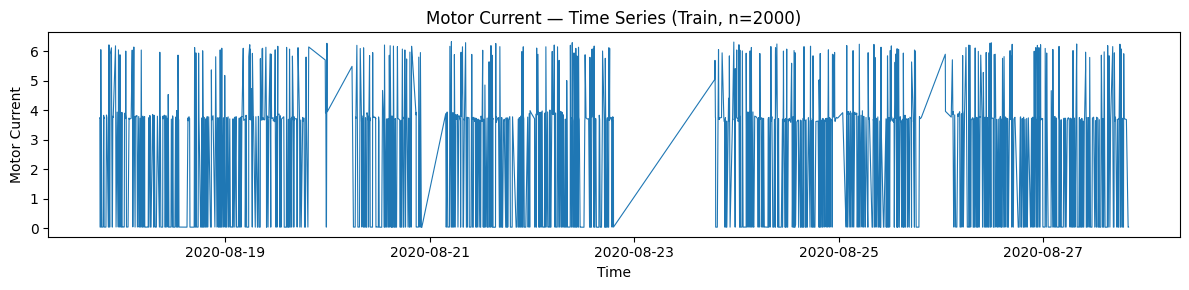

In [24]:
sample_ts = train_df.sample(2000, random_state=42).sort_values('timestamp')
plt.figure(figsize=(12, 3))
plt.plot(sample_ts['timestamp'], sample_ts['Motor_current'], linewidth=0.8)
plt.title("Motor Current — Time Series (Train, n=2000)")
plt.xlabel("Time")
plt.ylabel("Motor Current")
plt.tight_layout()
plt.show()

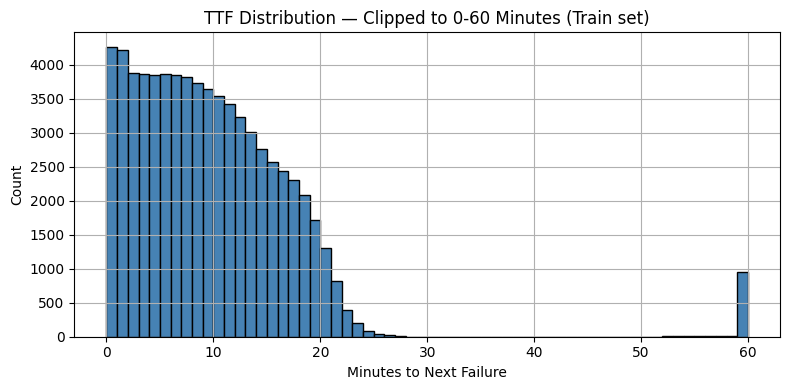

In [25]:
plt.figure(figsize=(8, 4))
train_df['TTF_minutes'].clip(0, 60).hist(bins=60, edgecolor='black', color='steelblue')
plt.title("TTF Distribution — Clipped to 0-60 Minutes (Train set)")
plt.xlabel("Minutes to Next Failure")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

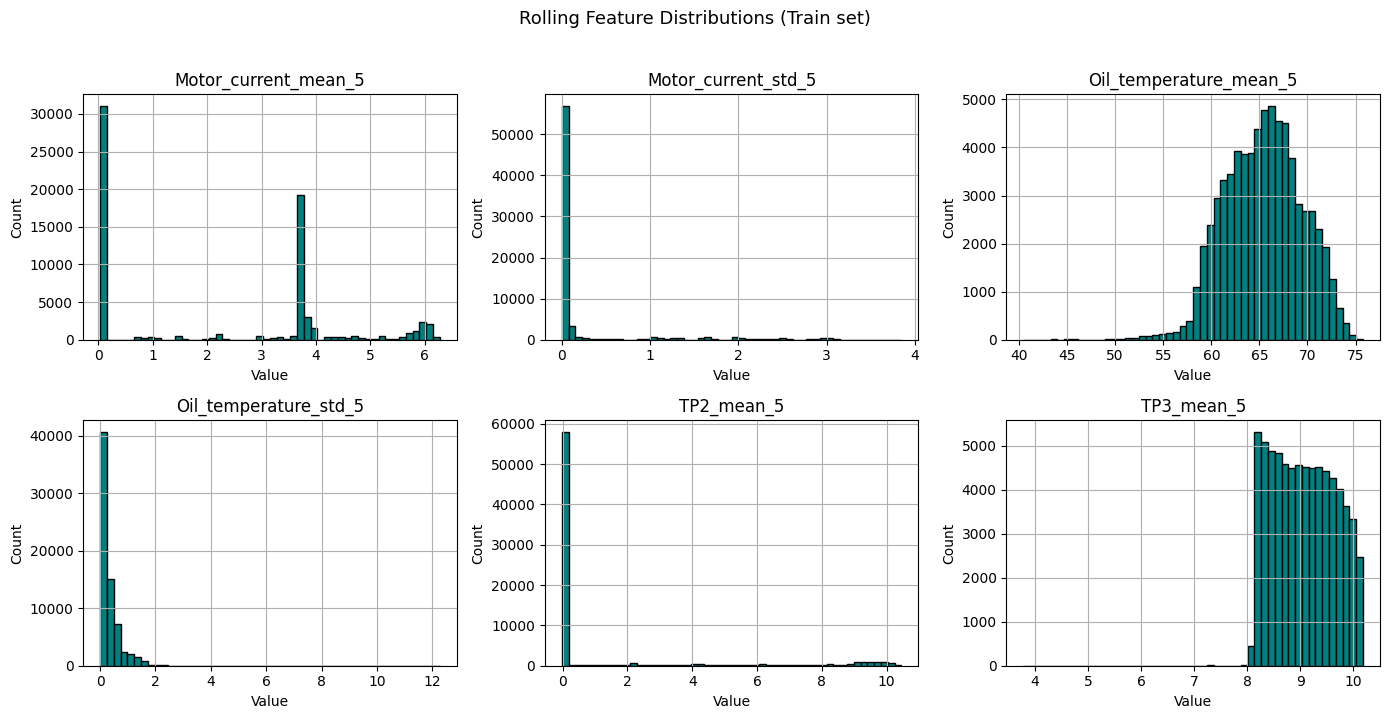

In [26]:
rolling_cols = ['Motor_current_mean_5', 'Motor_current_std_5',
                'Oil_temperature_mean_5', 'Oil_temperature_std_5',
                'TP2_mean_5', 'TP3_mean_5']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), rolling_cols):
    train_df[col].hist(bins=50, ax=ax, edgecolor='black', color='teal')
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
plt.suptitle("Rolling Feature Distributions (Train set)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 10. Class Imbalance — Class Weighting


In [27]:
classes = np.unique(y_train)
class_weights_array = compute_class_weight(
    class_weight='balanced', classes=classes, y=y_train
)
class_weights_dict = dict(zip(classes, class_weights_array))
print("Class weights:", class_weights_dict)


scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(scale_pos_weight, 4))

Class weights: {np.int64(0): np.float64(0.6072593517940176), np.int64(1): np.float64(2.83079909414429)}
scale_pos_weight: 4.6616


In [28]:
def find_optimal_threshold(model, X_val, y_val, model_type='sklearn'):

    if model_type == 'sklearn':
        y_prob = model.predict_proba(X_val)[:, 1]
    elif model_type == 'keras':
        y_prob = model.predict(X_val, verbose=0).flatten()

    precision, recall, thresholds = precision_recall_curve(y_val, y_prob)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
    best_idx = int(np.argmax(f1_scores))
    optimal_threshold = float(thresholds[best_idx]) if best_idx < len(thresholds) else 0.5
    print(f"  Optimal threshold: {optimal_threshold:.4f}  (F1 = {f1_scores[best_idx]:.4f})")
    return optimal_threshold


def evaluate_model(y_true, y_pred, y_prob, model_name):

    print(f"\n--- {model_name} ---")
    print("Accuracy: ", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred, zero_division=0), 4))
    print("Recall:   ", round(recall_score(y_true, y_pred, zero_division=0), 4))
    print("F1 Score: ", round(f1_score(y_true, y_pred, zero_division=0), 4))
    print("ROC AUC:  ", round(roc_auc_score(y_true, y_prob), 4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Failure', 'Failure'],
                yticklabels=['No Failure', 'Failure'])
    plt.title(f"Confusion Matrix — {model_name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    return {
        'Model':     model_name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC_AUC':   round(roc_auc_score(y_true, y_prob), 4)
    }

results_list = []
print("Helper functions defined successfully.")

Helper functions defined successfully.


## 11. Model 1 — Random Forest


In [29]:
tscv = TimeSeriesSplit(n_splits=3)

param_dist_rf = {
    'n_estimators':      [100, 200],
    'max_depth':         [10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2]
}

rf = RandomForestClassifier(
    class_weight=class_weights_dict, random_state=42, n_jobs=-1
)

random_search_rf = RandomizedSearchCV(
    rf, param_distributions=param_dist_rf,
    n_iter=4, scoring='f1', cv=tscv,
    verbose=1, random_state=42, n_jobs=-1
)
random_search_rf.fit(X_train, y_train)
best_rf = random_search_rf.best_estimator_
print("Best RF params:", random_search_rf.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best RF params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 15}


  Optimal threshold: 0.7198  (F1 = 0.8353)

--- Random Forest ---
Accuracy:  0.9498
Precision: 0.9639
Recall:    0.7442
F1 Score:  0.8399
ROC AUC:   0.9782


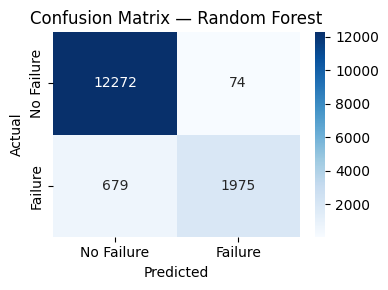

In [30]:
rf_threshold = find_optimal_threshold(best_rf, X_val, y_val, model_type='sklearn')

rf_prob = best_rf.predict_proba(X_test)[:, 1]
rf_pred = (rf_prob >= rf_threshold).astype(int)
rf_results = evaluate_model(y_test, rf_pred, rf_prob, "Random Forest")
results_list.append(rf_results)

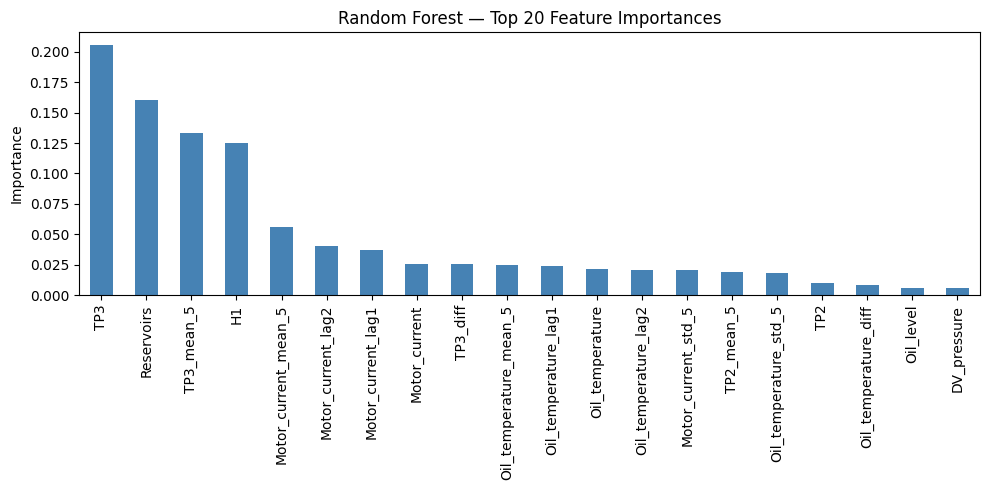

In [31]:
importances = pd.Series(best_rf.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
importances.head(20).plot(kind='bar', color='steelblue')
plt.title("Random Forest — Top 20 Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

## 12. Model 2 — XGBoost


In [32]:
param_dist_xgb = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [4, 6, 8],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_clf = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42, n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)

random_search_xgb = RandomizedSearchCV(
    xgb_clf, param_distributions=param_dist_xgb,
    n_iter=10, scoring='f1', cv=tscv,
    verbose=1, random_state=42, n_jobs=-1
)
random_search_xgb.fit(X_train, y_train)
best_xgb = random_search_xgb.best_estimator_
print("Best XGB params:", random_search_xgb.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGB params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


  Optimal threshold: 0.7968  (F1 = 0.8424)

--- XGBoost ---
Accuracy:  0.9497
Precision: 0.9468
Recall:    0.7585
F1 Score:  0.8423
ROC AUC:   0.9809


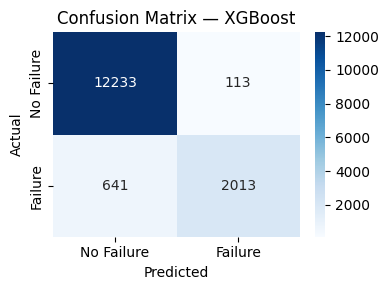

In [33]:
xgb_threshold = find_optimal_threshold(best_xgb, X_val, y_val, model_type='sklearn')

xgb_prob = best_xgb.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_prob >= xgb_threshold).astype(int)
xgb_results = evaluate_model(y_test, xgb_pred, xgb_prob, "XGBoost")
results_list.append(xgb_results)

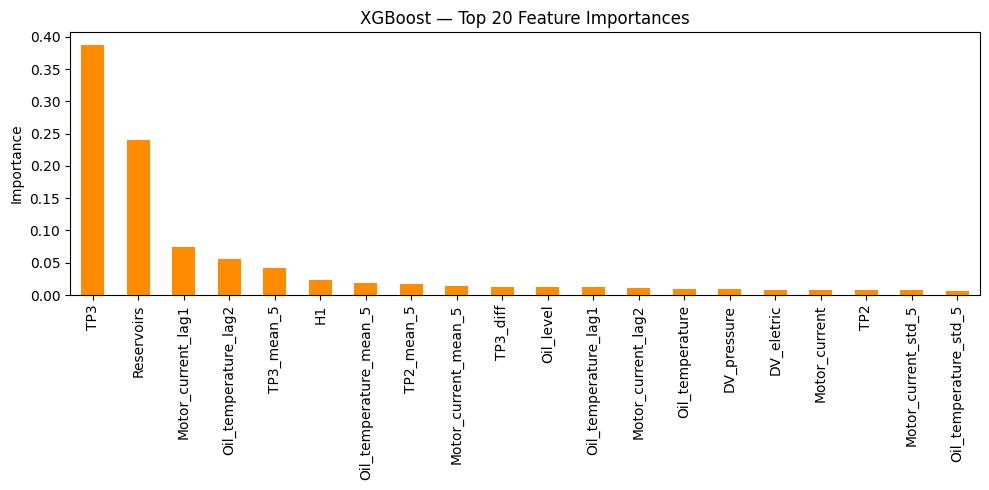

In [34]:
xgb_imp = pd.Series(best_xgb.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
xgb_imp.head(20).plot(kind='bar', color='darkorange')
plt.title("XGBoost — Top 20 Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

## 13. Model 3 — LSTM


In [35]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)
print("Scaling done. Train mean ~0:", X_train_scaled.mean().round(4))

Scaling done. Train mean ~0: 0.0


In [36]:
def create_sequences_safe(X, y, timestamps, window_size, max_gap_sec=300):
    """Only create sequences within continuous time blocks."""
    X_seq, y_seq = [], []
    ts = pd.to_datetime(timestamps).reset_index(drop=True)
    X = np.array(X)
    y = np.array(y)
    for i in range(window_size, len(X)):
        block_ts = ts.iloc[i - window_size:i + 1]
        diffs = block_ts.diff().dt.total_seconds().dropna()
        if diffs.max() > max_gap_sec:
            continue
        X_seq.append(X[i - window_size:i])
        y_seq.append(y[i])
    if len(X_seq) == 0:
        return np.empty((0, window_size, X.shape[1])), np.empty((0,))
    return np.array(X_seq), np.array(y_seq)

window_size = 5

X_train_seq, y_train_seq = create_sequences_safe(
    X_train_scaled, y_train.values, train_df['timestamp'].reset_index(drop=True), window_size)
X_val_seq, y_val_seq = create_sequences_safe(
    X_val_scaled, y_val.values, val_df['timestamp'].reset_index(drop=True), window_size)
X_test_seq, y_test_seq = create_sequences_safe(
    X_test_scaled, y_test.values, test_df['timestamp'].reset_index(drop=True), window_size)

print("Sequence shapes:")
print("  Train:", X_train_seq.shape)
print("  Val:  ", X_val_seq.shape)
print("  Test: ", X_test_seq.shape)
print("  Train class dist:", dict(zip(*np.unique(y_train_seq, return_counts=True))))

Sequence shapes:
  Train: (69925, 5, 30)
  Val:   (14975, 5, 30)
  Test:  (14970, 5, 30)
  Train class dist: {np.int64(0): np.int64(57569), np.int64(1): np.int64(12356)}


In [37]:
classes_seq  = np.unique(y_train_seq)
cw_array_seq = compute_class_weight(
    class_weight='balanced', classes=classes_seq, y=y_train_seq
)
cw_dict_seq = dict(zip(classes_seq, cw_array_seq))
print("Sequence-level class weights:", cw_dict_seq)

Sequence-level class weights: {np.int64(0): np.float64(0.6073147006201254), np.int64(1): np.float64(2.8295969569439947)}


In [38]:
lstm_model = Sequential([
    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
lstm_model.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 128)         │        81,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,929 (519.25 KB)

 Trainable params: 132,929 (519.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9011 - loss: 0.2320 - val_accuracy: 0.9186 - val_loss: 0.1930
Epoch 2/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9309 - loss: 0.1851 - val_accuracy: 0.9244 - val_loss: 0.1897
Epoch 3/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9335 - loss: 0.1793 - val_accuracy: 0.9302 - val_loss: 0.1827
Epoch 4/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9354 - loss: 0.1759 - val_accuracy: 0.9257 - val_loss: 0.1905
Epoch 5/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9356 - loss: 0.1736 - val_accuracy: 0.9215 - val_loss: 0.1850
Epoch 6/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9365 - loss: 0.1701 - val_accuracy: 0.9250 - val_loss: 0.1826
Epoch 7/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9364 - loss: 0.1690 - val_accuracy: 0.9330 - val_loss: 0.1708
Epoch 8/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9373 - loss: 0.1681 - val_accura

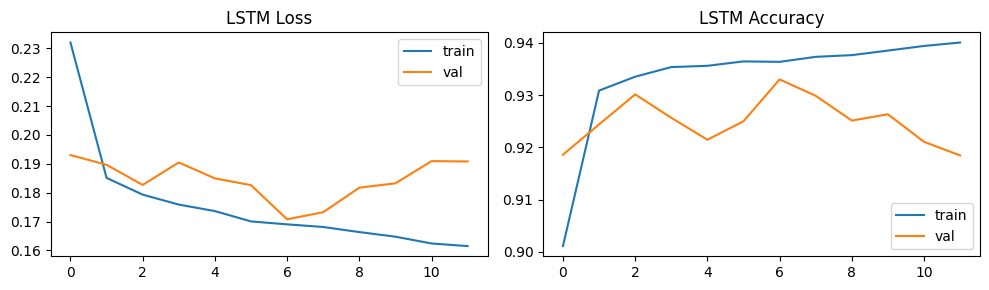

In [39]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50, batch_size=128,
    class_weight=cw_dict_seq,
    callbacks=[early_stop],
    verbose=1
)

plt.figure(figsize=(10, 3))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("LSTM Loss"); plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("LSTM Accuracy"); plt.legend()
plt.tight_layout(); plt.show()

  Optimal threshold: 0.6982  (F1 = 0.8413)

--- LSTM ---
Accuracy:  0.9493
Precision: 0.9204
Recall:    0.7811
F1 Score:  0.8451
ROC AUC:   0.9788


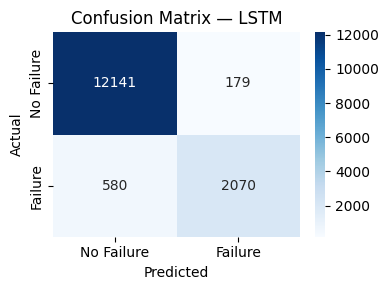

In [40]:
lstm_threshold = find_optimal_threshold(lstm_model, X_val_seq, y_val_seq, model_type='keras')

lstm_prob = lstm_model.predict(X_test_seq, verbose=0).flatten()
lstm_prob = np.nan_to_num(lstm_prob)
lstm_pred = (lstm_prob >= lstm_threshold).astype(int)
lstm_results = evaluate_model(y_test_seq, lstm_pred, lstm_prob, "LSTM")
results_list.append(lstm_results)

## 14. Model 4 — Transformer


In [41]:
inputs = tf.keras.Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2]))

attn_out = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
attn_out = Dropout(0.1)(attn_out)
x        = LayerNormalization(epsilon=1e-6)(inputs + attn_out)

ff = Dense(64, activation='relu')(x)
ff = Dense(X_train_seq.shape[2])(ff)
x  = LayerNormalization(epsilon=1e-6)(x + ff)

x       = GlobalAveragePooling1D()(x)
x       = Dense(32, activation='relu')(x)
x       = Dropout(0.2)(x)
outputs = Dense(1, activation='sigmoid')(x)

transformer_model = Model(inputs, outputs)
transformer_model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
transformer_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 5, 30)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 5, 30)     │     15,774 │ input_layer_1[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 5, 30)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 5, 30)     │          0 │ input_layer_1[0]… │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 5, 30)     │         60 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 5, 64)     │      1,984 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 5, 30)     │      1,950 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 5, 30)     │          0 │ layer_normalizat… │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 5, 30)     │         60 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 30)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │        992 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         33 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,853 (81.46 KB)

 Trainable params: 20,853 (81.46 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.9007 - loss: 0.2448 - val_accuracy: 0.9236 - val_loss: 0.1866 - learning_rate: 3.0000e-04
Epoch 2/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9274 - loss: 0.1941 - val_accuracy: 0.9215 - val_loss: 0.1987 - learning_rate: 3.0000e-04
Epoch 3/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9310 - loss: 0.1867 - val_accuracy: 0.9280 - val_loss: 0.1803 - learning_rate: 3.0000e-04
Epoch 4/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9321 - loss: 0.1824 - val_accuracy: 0.9231 - val_loss: 0.1904 - learning_rate: 3.0000e-04
Epoch 5/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9342 - loss: 0.1796 - val_accuracy: 0.9306 - val_loss: 0.1757 - learning_rate: 3.0000e-04
Epoch 6/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9351 - loss: 0.1768 - val_accuracy: 0.9310 - val_loss: 0.1732 - learning_rate: 3.0000e-04
Epoch 7/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy

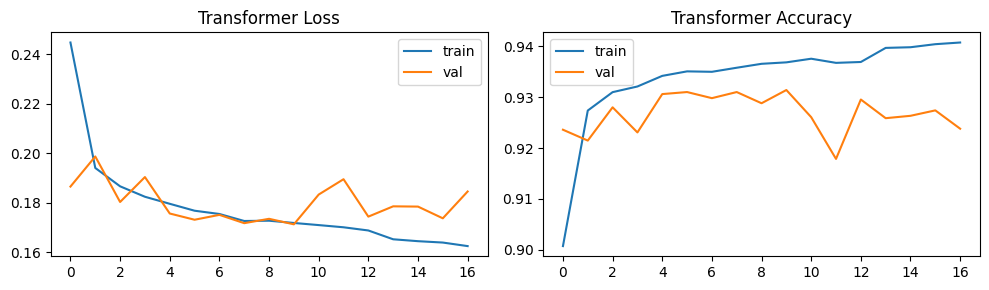

In [42]:
early_stop_tf = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0
)

history_tf = transformer_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50, batch_size=128,
    class_weight=cw_dict_seq,
    callbacks=[early_stop_tf, reduce_lr],
    verbose=1
)

plt.figure(figsize=(10, 3))
plt.subplot(1,2,1)
plt.plot(history_tf.history['loss'], label='train')
plt.plot(history_tf.history['val_loss'], label='val')
plt.title("Transformer Loss"); plt.legend()
plt.subplot(1,2,2)
plt.plot(history_tf.history['accuracy'], label='train')
plt.plot(history_tf.history['val_accuracy'], label='val')
plt.title("Transformer Accuracy"); plt.legend()
plt.tight_layout(); plt.show()

Optimal threshold: 0.6733

--- Transformer ---
Accuracy:  0.9486
Precision: 0.8772
Recall:    0.8249
F1 Score:  0.8503
ROC AUC:   0.9805


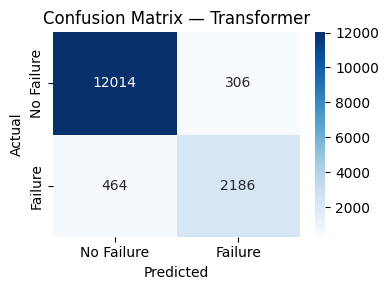

In [43]:

tf_prob = transformer_model.predict(X_test_seq, verbose=0).flatten()
tf_prob = np.nan_to_num(tf_prob)

precision, recall, thresholds = precision_recall_curve(y_test_seq, tf_prob)
f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)
tf_threshold = thresholds[best_idx]
print(f"Optimal threshold: {tf_threshold:.4f}")

tf_pred = (tf_prob >= tf_threshold).astype(int)
tf_results = evaluate_model(y_test_seq, tf_pred, tf_prob, "Transformer")
results_list.append(tf_results)

## 15. Model 5 — RUL Regression (Random Forest Regressor)
Predict exact minutes until next failure. TTF clipped to 0-60 min to reduce noise
from very long-horizon predictions. Evaluated with MAE, RMSE, and R².

In [44]:
df['TTF_clipped'] = df['TTF_minutes'].clip(lower=0, upper=60)

rul_exclude  = ['timestamp', 'failure_event', 'next_failure_time',
                'TTF_minutes', 'TTF_clipped', 'failure_next_3min']
rul_features = [c for c in df.columns if c not in rul_exclude]
print(f"RUL features ({len(rul_features)}):", rul_features)

RUL features (30): ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current', 'COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses', 'time_diff', 'Motor_current_mean_5', 'Motor_current_std_5', 'Oil_temperature_mean_5', 'Oil_temperature_std_5', 'TP2_mean_5', 'TP3_mean_5', 'Motor_current_diff', 'Oil_temperature_diff', 'TP2_diff', 'TP3_diff', 'Motor_current_lag1', 'Motor_current_lag2', 'Oil_temperature_lag1', 'Oil_temperature_lag2']


In [45]:
X_rul = df[rul_features].dropna()
y_rul = df.loc[X_rul.index, 'TTF_clipped']

n_rul         = len(X_rul)
rul_train_end = int(n_rul * 0.70)
rul_val_end   = int(n_rul * 0.85)

X_train_rul = X_rul.iloc[:rul_train_end]
y_train_rul = y_rul.iloc[:rul_train_end]
X_val_rul   = X_rul.iloc[rul_train_end:rul_val_end]
y_val_rul   = y_rul.iloc[rul_train_end:rul_val_end]
X_test_rul  = X_rul.iloc[rul_val_end:]
y_test_rul  = y_rul.iloc[rul_val_end:]

print("RUL Train:", X_train_rul.shape)
print("RUL Val:  ", X_val_rul.shape)
print("RUL Test: ", X_test_rul.shape)

RUL Train: (70000, 30)
RUL Val:   (15000, 30)
RUL Test:  (15000, 30)


In [46]:
rul_model = RandomForestRegressor(
    n_estimators=200, max_depth=15,
    random_state=42, n_jobs=-1
)
rul_model.fit(X_train_rul, y_train_rul)
print("RUL model trained.")

RUL model trained.


In [47]:
y_pred_rul = rul_model.predict(X_test_rul)

rul_mae  = mean_absolute_error(y_test_rul, y_pred_rul)
rul_rmse = np.sqrt(mean_squared_error(y_test_rul, y_pred_rul))
rul_r2   = r2_score(y_test_rul, y_pred_rul)

print("--- RUL Regression Model ---")
print(f"MAE:      {rul_mae:.3f} minutes")
print(f"RMSE:     {rul_rmse:.3f} minutes")
print(f"R2 Score: {rul_r2:.4f}")

--- RUL Regression Model ---
MAE:      2.955 minutes
RMSE:     6.584 minutes
R2 Score: 0.3619


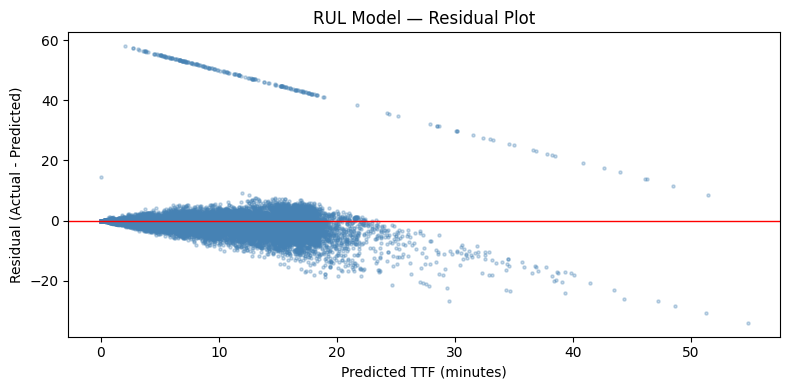

In [48]:
residuals = y_test_rul.values - y_pred_rul
plt.figure(figsize=(8, 4))
plt.scatter(y_pred_rul, residuals, alpha=0.3, s=5, color='steelblue')
plt.axhline(0, color='red', linewidth=1)
plt.xlabel("Predicted TTF (minutes)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("RUL Model — Residual Plot")
plt.tight_layout()
plt.show()

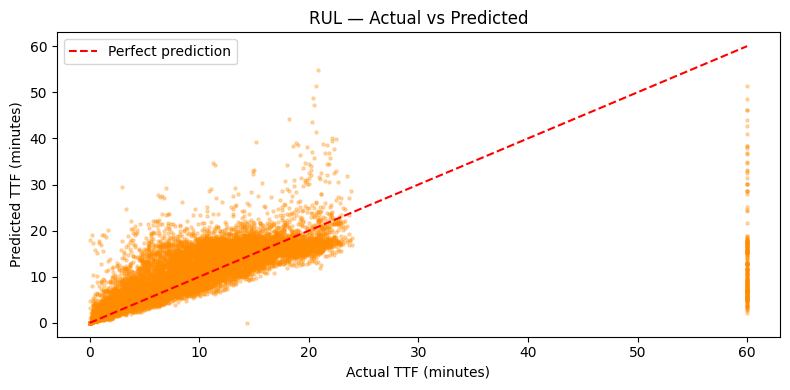

In [49]:
plt.figure(figsize=(8, 4))
plt.scatter(y_test_rul, y_pred_rul, alpha=0.3, s=5, color='darkorange')
plt.plot([0, 60], [0, 60], 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel("Actual TTF (minutes)")
plt.ylabel("Predicted TTF (minutes)")
plt.title("RUL — Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

## 16. Results Comparison
Side-by-side table and bar charts comparing all four classifiers on F1 and ROC-AUC.
RUL regression metrics printed separately at the end.

In [50]:
results_df = pd.DataFrame(results_list)
print("\n CLASSIFICATION MODEL COMPARISON ")
print(results_df.to_string(index=False))


 CLASSIFICATION MODEL COMPARISON 
        Model  Accuracy  Precision  Recall     F1  ROC_AUC
Random Forest    0.9498     0.9639  0.7442 0.8399   0.9782
      XGBoost    0.9497     0.9468  0.7585 0.8423   0.9809
         LSTM    0.9493     0.9204  0.7811 0.8451   0.9788
  Transformer    0.9486     0.8772  0.8249 0.8503   0.9805


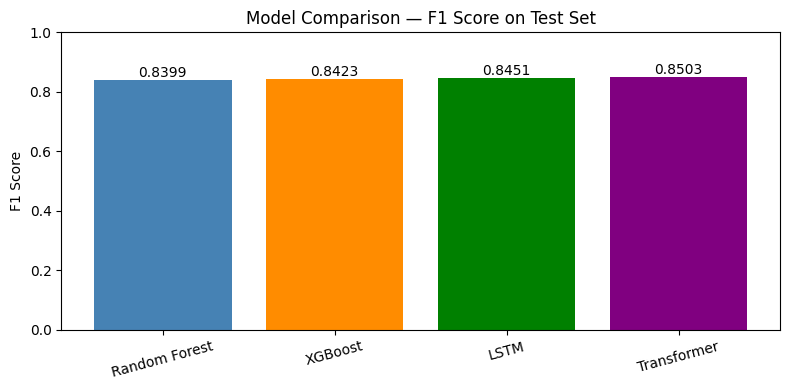

In [51]:
plt.figure(figsize=(8, 4))
colors = ['steelblue', 'darkorange', 'green', 'purple']
plt.bar(results_df['Model'], results_df['F1'], color=colors)
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.title("Model Comparison — F1 Score on Test Set")
plt.xticks(rotation=15)
for i, v in enumerate(results_df['F1']):
    plt.text(i, v + 0.01, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

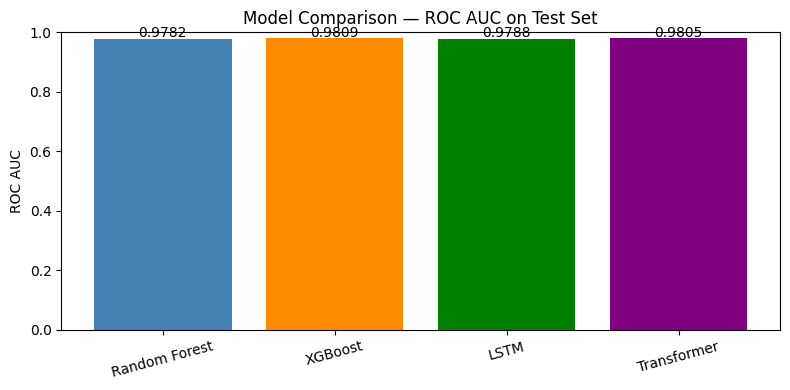

In [52]:
plt.figure(figsize=(8, 4))
plt.bar(results_df['Model'], results_df['ROC_AUC'], color=colors)
plt.ylabel("ROC AUC")
plt.ylim(0, 1)
plt.title("Model Comparison — ROC AUC on Test Set")
plt.xticks(rotation=15)
for i, v in enumerate(results_df['ROC_AUC']):
    plt.text(i, v + 0.005, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [53]:
print("\n RUL REGRESSION MODEL ")
print(f"MAE:      {rul_mae:.3f} minutes")
print(f"RMSE:     {rul_rmse:.3f} minutes")
print(f"R2 Score: {rul_r2:.4f}")
print("\nAll models trained and evaluated successfully.")


 RUL REGRESSION MODEL 
MAE:      2.955 minutes
RMSE:     6.584 minutes
R2 Score: 0.3619

All models trained and evaluated successfully.


In [54]:
import joblib
import os

SAVE_DIR = '/content/drive/MyDrive/equipment_failure_detection/saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(best_rf,    f'{SAVE_DIR}/rf_model.pkl')
joblib.dump(best_xgb,   f'{SAVE_DIR}/xgb_model.pkl')
joblib.dump(rul_model,  f'{SAVE_DIR}/rul_model.pkl')

joblib.dump(scaler,     f'{SAVE_DIR}/scaler.pkl')

joblib.dump(features,   f'{SAVE_DIR}/features.pkl')

joblib.dump(rf_threshold,  f'{SAVE_DIR}/rf_threshold.pkl')
joblib.dump(xgb_threshold, f'{SAVE_DIR}/xgb_threshold.pkl')

joblib.dump(X_test.iloc[[0]], f'{SAVE_DIR}/sample_input.pkl')

print("Saved files:")
for f in os.listdir(SAVE_DIR):
    size = os.path.getsize(f'{SAVE_DIR}/{f}')
    print(f"  {f} — {size/1024:.1f} KB")

Saved files:
  rf_model.pkl — 20048.7 KB
  xgb_model.pkl — 938.5 KB
  rul_model.pkl — 176391.9 KB
  scaler.pkl — 2.0 KB
  features.pkl — 0.5 KB
  rf_threshold.pkl — 0.0 KB
  xgb_threshold.pkl — 0.0 KB
  sample_input.pkl — 1.6 KB
